In [1]:
import drms
import pandas as pd


In [2]:
client = drms.Client(email='mpoisson@iafe.uba.ar')

# MDI-TARPS

In [3]:
ar_number='8040'

dic={}

# Function to find a number within strings in a list
def find_number_in_strings(number, strings):
    for string in strings:
      if str(number) in string:
        return string  # Return the string if the number is found
    return None # Return None if not found

ds = 'mdi.Mtarp[][1997.01.01_00:00:00_TAI/365d]{magnetogram}'
k = client.query(ds, key='T_REC,HARPNUM,NOAA_ARS')
# Use the find_number_in_strings function to search k['NOAA_ARS']
found_string = find_number_in_strings(ar_number, k['NOAA_ARS'].values)

if found_string:
    # Find the corresponding HARPNUM using the found string
    harpnum_index = list(k['NOAA_ARS']).index(found_string)  # Find the index of the matching NOAA_ARS string
    harpnum = k['HARPNUM'][harpnum_index]
    print(str(ar_number) + ' found in ' + str(harpnum))
    dic[ar_number]=harpnum

else:
    print('----------------------------')
    print(str(ar_number) + ' not found')

8040 found in 362


# SHARPS

In [4]:
si = client.info('hmi.sharp_cea_720s')   

In [5]:
k = client.query('hmi.sharp_cea_720s[][2012.05.09_TAI/5d][? NOAA_ARS ~ "11476" ?]',key='T_REC,NOAA_ARS,HARPNUM')

In [7]:
harpnum=1638
#tstart='2012.05.07_00:00:00'
tstart='2012.05.09_00:00:00'
extent='1d'
cadence='12m'


ds = 'hmi.sharp_cea_720s['+ str(harpnum) + ']['+ tstart+'_TAI/' + extent + '@' + cadence +']{Br}'

k = client.query(ds,key='T_REC,NOAA_ARS')

k

,T_REC,NOAA_ARS
0,2012.05.09_00:12:00_TAI,11476
1,2012.05.09_00:24:00_TAI,11476
2,2012.05.09_00:36:00_TAI,11476
3,2012.05.09_00:48:00_TAI,11476
4,2012.05.09_01:00:00_TAI,11476
...,...,...
111,2012.05.09_22:24:00_TAI,11476
112,2012.05.09_22:36:00_TAI,11476
113,2012.05.09_22:48:00_TAI,11476
114,2012.05.09_23:00:00_TAI,11476


In [19]:
import drms
import pandas as pd

client = drms.Client()

tstart = '2012.01.01_00:00:00'
extent = '30d'
cadence = '1h'

ds = f'hmi.sharp_cea_720s[][{tstart}_TAI/{extent}@{cadence}]'

keys = ['T_REC', 'NOAA_ARS','HARPNUM','MTOT','USFLUX','LON_MAX','LON_MIN','LAT_MAX','LAT_MIN','SIZE']

df = client.query(ds, key=keys)

In [20]:
df

,T_REC,NOAA_ARS,HARPNUM,MTOT,USFLUX,LON_MAX,LON_MIN,LAT_MAX,LAT_MIN,SIZE
0,2012.01.01_00:00:00_TAI,"11383,11384",1221,902028.000000,7.027317e+21,89.171814,74.971733,14.243658,8.141366,711.267456
1,2012.01.01_01:00:00_TAI,"11383,11384",1221,847013.312500,5.299230e+21,89.411530,75.418243,14.246455,8.123275,655.837524
2,2012.01.01_02:00:00_TAI,"11383,11384",1221,772398.000000,4.546245e+21,89.343399,75.943062,14.257819,8.124416,598.868469
3,2012.01.01_03:00:00_TAI,"11383,11384",1221,692960.375000,4.208917e+21,89.299057,76.508560,14.249873,8.127398,542.731628
4,2012.01.01_04:00:00_TAI,"11383,11384",1221,606963.687500,4.089614e+21,89.368767,77.075951,14.251315,8.114635,486.756073
...,...,...,...,...,...,...,...,...,...,...
7403,2012.01.30_19:00:00_TAI,MISSING,1368,173244.406250,3.639183e+20,-39.195915,-42.133099,12.089102,10.601160,238.381058
7404,2012.01.30_20:00:00_TAI,MISSING,1368,177295.203125,3.336069e+20,-38.616596,-41.714661,12.091909,10.591271,255.518478
7405,2012.01.30_21:00:00_TAI,MISSING,1368,183369.296875,3.297968e+20,-38.042091,-41.286850,12.145675,10.606547,276.926636
7406,2012.01.30_22:00:00_TAI,MISSING,1368,190933.796875,3.806514e+20,-37.471725,-40.815300,12.187465,10.601957,295.446045


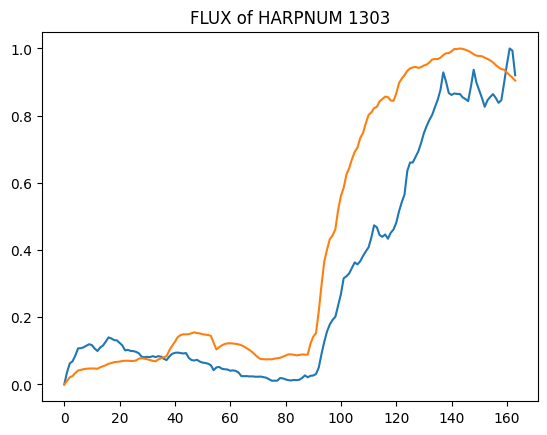

0.95


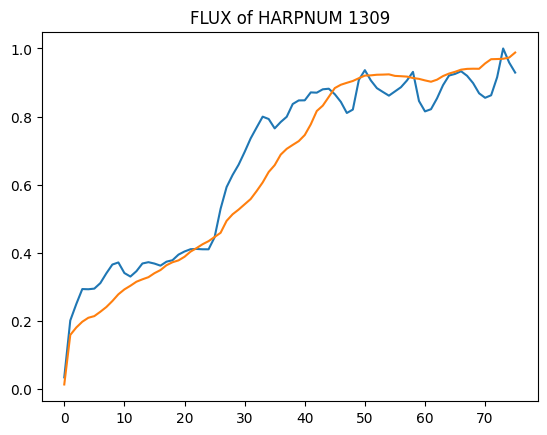

0.97


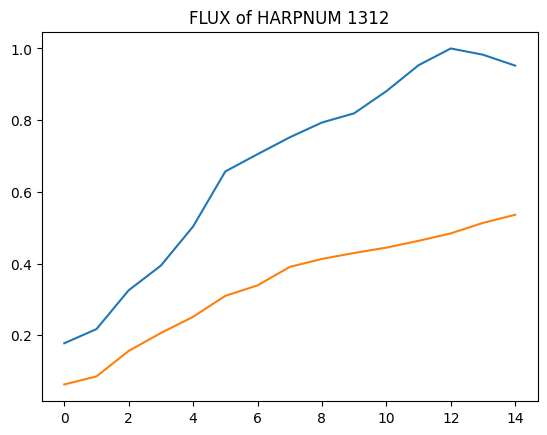

0.99


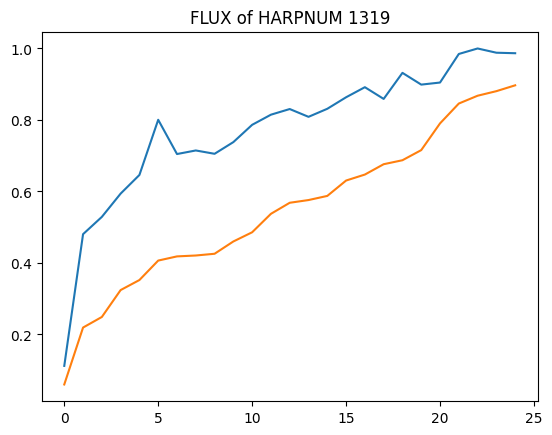

0.93


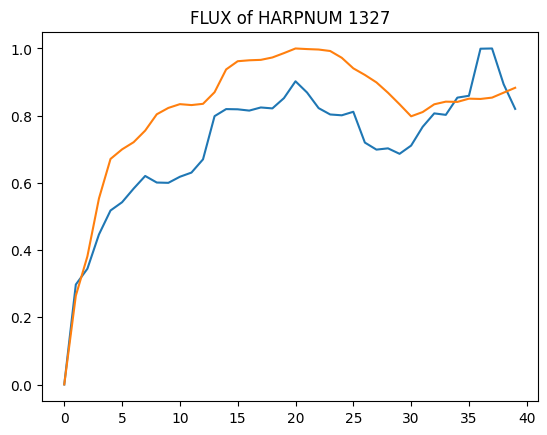

0.89


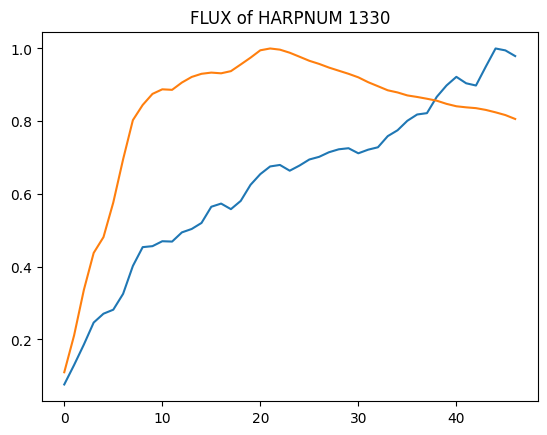

0.64
6 from 67


In [52]:
import matplotlib.pyplot as plt
import numpy as np

DF0=[]

df=df.assign(LON=lambda x: (x.LON_MAX + x.LON_MIN)/2)
df=df.assign(LAT=lambda x: (x.LAT_MAX + x.LAT_MIN)/2)

i=0
for harpn in df.HARPNUM.unique():
    df_harpn = df[df.HARPNUM == harpn]
    df_harpn = df_harpn[df_harpn.LON.between(-60,60)]
    df_harpn = df_harpn[df_harpn.LAT.between(-60,60)]
    df_harpn = df_harpn.sort_values(by='T_REC')
    df_harpn = df_harpn.assign(NormF=lambda x: x.USFLUX/np.max(x.USFLUX))
    df_harpn = df_harpn.assign(NormS=lambda x: x.SIZE/np.max(x.SIZE)).reset_index(drop=True)
    
    try:
        idxmax = df_harpn['NormF'].idxmax()
    except ValueError:
        continue
    df_harpn = df_harpn.loc[0:idxmax+2]
    if df_harpn.NOAA_ARS.unique() == 'MISSING':
        continue
    if len(df_harpn.NOAA_ARS.unique()[0]) >5:
        continue 
    if len(df_harpn) <10:
        continue
    if np.median(np.gradient(df_harpn['NormF'])) < 0:
        continue
    if np.gradient(df_harpn['NormS']).mean() < 0:
        continue
    if df_harpn['NormF'].iloc[0] > 0.2:
        continue
    if np.corrcoef(df_harpn['NormF'], df_harpn['NormS'])[0,1] < 0.6:
        continue
    #print(f'HARPNUM: {harpn}, Entries: {len(df_harpn)}')
    flux_values = df_harpn['NormF'].values
    size_values = df_harpn['NormS'].values
    plt.plot(flux_values)
    plt.plot(size_values)
    plt.title(f'FLUX of HARPNUM {harpn}')
    plt.show()
    print(f'{np.corrcoef(flux_values, size_values)[0,1]:.2f}')
    DF0.append(df_harpn)
    i+=1
print(f'{i} from {len(df.HARPNUM.unique())}')
    #plt.plot(flux_values/np.max(flux_values))
    #plt.title(f'FLUX of HARPNUM {harpn}')
    #plt.show()

DF0=pd.concat(DF0).reset_index(drop=True)

In [104]:
def testharpnum(df):
    harps=[]
    df=df.assign(LAT=lambda x: (x.LAT_MAX + x.LAT_MIN)/2)
    for harpn in df.HARPNUM.unique():
        df_harpn = df[df.HARPNUM == harpn]
        if df_harpn.NOAA_ARS.unique() == 'MISSING':
            continue
        if len(df_harpn.NOAA_ARS.unique()[0]) >5:
            continue
   #     if df_harpn[~df_harpn.LAT.between(-60,60)]:
   #         continue
        harps.append(harpn)

    return harps 

    

In [109]:
def test_ARs(df):
   # DF0=[]

    df=df.assign(LON=lambda x: (x.LON_MAX + x.LON_MIN)/2)
    df=df.assign(LAT=lambda x: (x.LAT_MAX + x.LAT_MIN)/2)



    df_harpn = df[df.LON.between(-60,60)]
    df_harpn = df_harpn.sort_values(by='T_REC')
    df_harpn = df_harpn.assign(NormF=lambda x: x.USFLUX/np.max(x.USFLUX))
    df_harpn = df_harpn.assign(NormS=lambda x: x.SIZE/np.max(x.SIZE)).reset_index(drop=True)
    
    try:
        idxmax = df_harpn['NormF'].idxmax()
    except ValueError:
        return None
    df_harpn = df_harpn.loc[0:idxmax+2]
    if len(df_harpn) <10:
        return None
    if np.median(np.gradient(df_harpn['NormF'])) < 0:
        return None
    if np.gradient(df_harpn['NormS']).mean() < 0:
        return None
    if df_harpn['NormF'].iloc[0] > 0.2:
        return None
    if np.corrcoef(df_harpn['NormF'], df_harpn['NormS'])[0,1] < 0.6:
        return None
    #print(f'HARPNUM: {harpn}, Entries: {len(df_harpn)}')
    flux_values = df_harpn['NormF'].values
    size_values = df_harpn['NormS'].values
#    plt.plot(flux_values)
#    plt.plot(size_values)
#    plt.title(f'FLUX of HARPNUM {harpn}')
#    plt.show()
    #   print(f'{np.corrcoef(flux_values, size_values)[0,1]:.2f}')
  #  DF0.append(df_harpn)

    #plt.plot(flux_values/np.max(flux_values))
    #plt.title(f'FLUX of HARPNUM {harpn}')
    #plt.show()

    #DF0=pd.concat(DF0).reset_index(drop=True)

    return df_harpn

In [126]:
year=2014

In [127]:
harps=[]
for hh in np.arange(1,13,1):
    #print(f'{hh:02}')   
    tstart = f'{year}.{hh:02}.01_00:00:00'
    extent = '30d'
    cadence = '1h'

    ds = f'hmi.sharp_cea_720s[][{tstart}_TAI/{extent}@{cadence}]'

    keys = ['T_REC', 'NOAA_ARS','HARPNUM','MTOT','USFLUX','LON_MAX','LON_MIN','LAT_MAX','LAT_MIN','SIZE']

    df = client.query(ds, key=keys)
    harps0 = testharpnum(df)
    harps.append(harps0)

#DF1=pd.concat(DF1).reset_index(drop=True)


In [128]:
harps_unique = set()
for sublist in harps:
    for item in sublist:
        harps_unique.add(str(item))

In [121]:
DF1=[]
for hh in list(harps_unique):
    #print(f'{hh:02}')   
    tstart = f'{year}.01.01_00:00:00'
    extent = '366d'
    cadence = '1h'

    ds = f'hmi.sharp_cea_720s[{hh}][{tstart}_TAI/{extent}@{cadence}]'

    keys = ['T_REC', 'NOAA_ARS','HARPNUM','MTOT','USFLUX','LON_MAX','LON_MIN','LAT_MAX','LAT_MIN','SIZE']

    df = client.query(ds, key=keys)
    DF0 = test_ARs(df)
    if DF0 is not None:
        DF1.append(DF0)

DF1=pd.concat(DF1).reset_index(drop=True)

#ds = 'hmi.sharp_cea_720s['+ str(harpnum) + ']['+ tstart+'_TAI/' + extent + '@' + cadence +']{Br, Bp, Bt, bitmap}'

In [125]:
len(DF1.NOAA_ARS.unique())

59

In [123]:
DF1.to_csv(f'HARPS_SELECTED_{year}.csv', index=False)

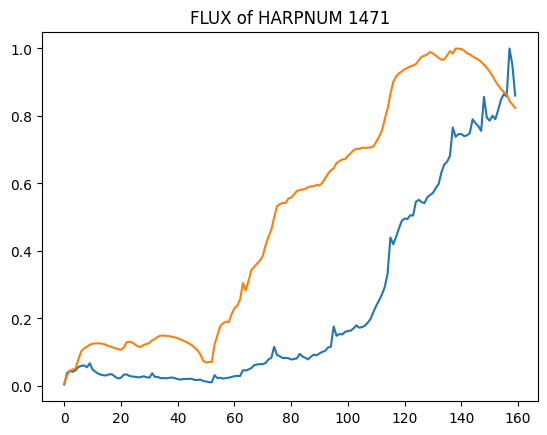

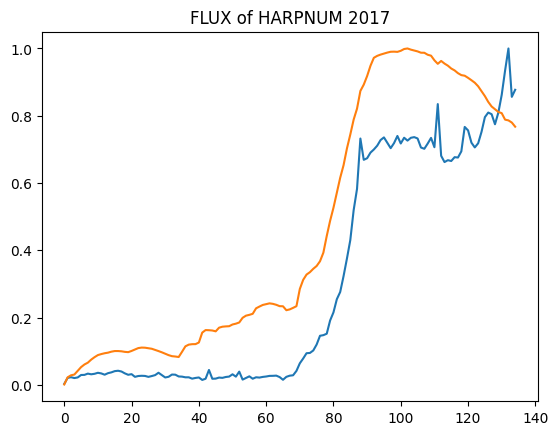

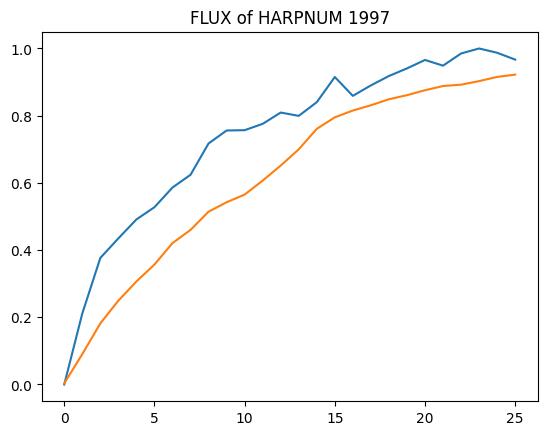

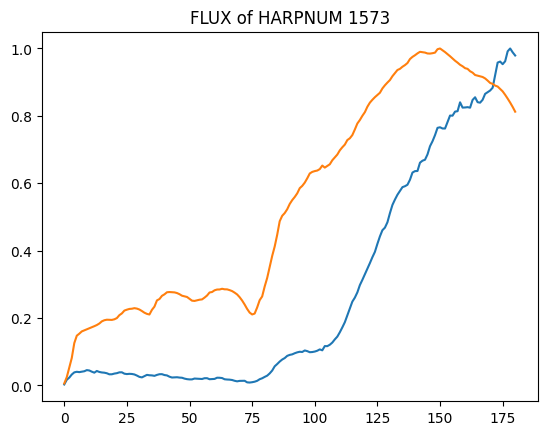

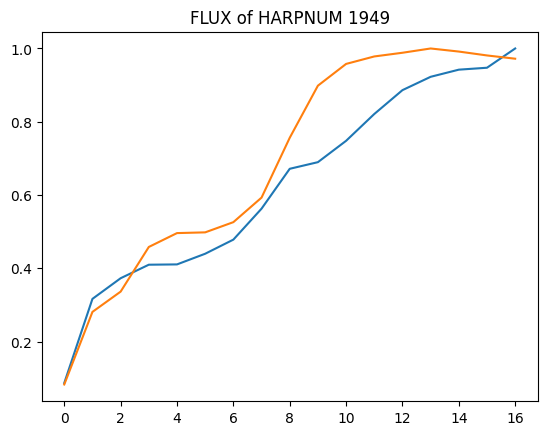

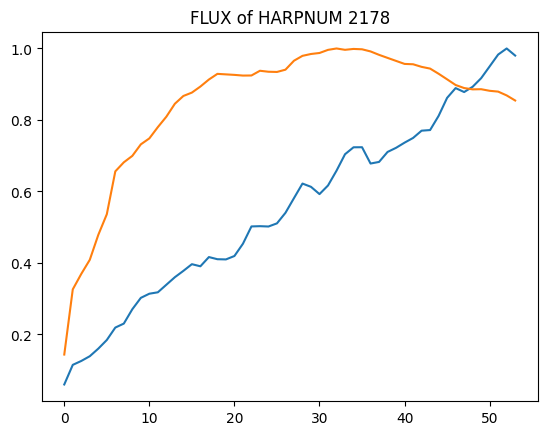

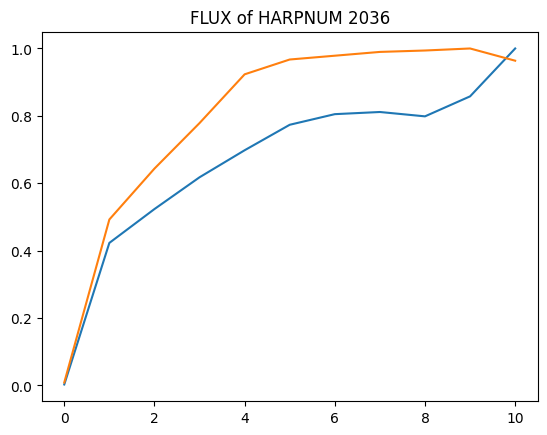

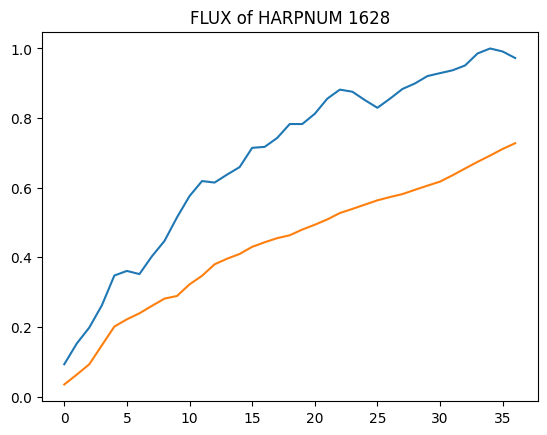

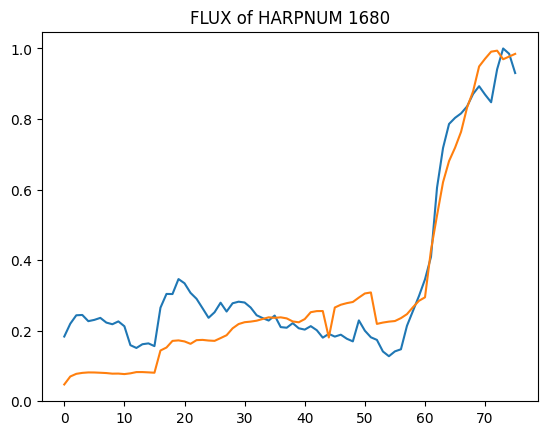

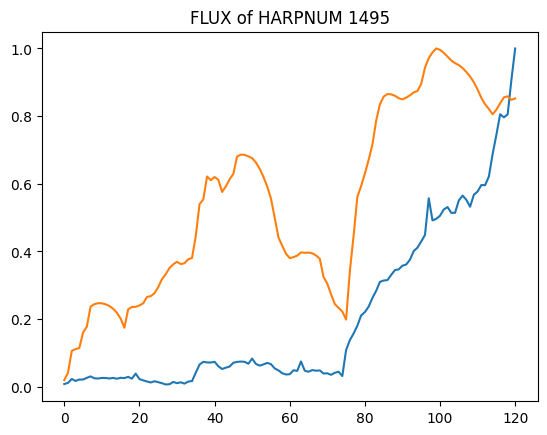

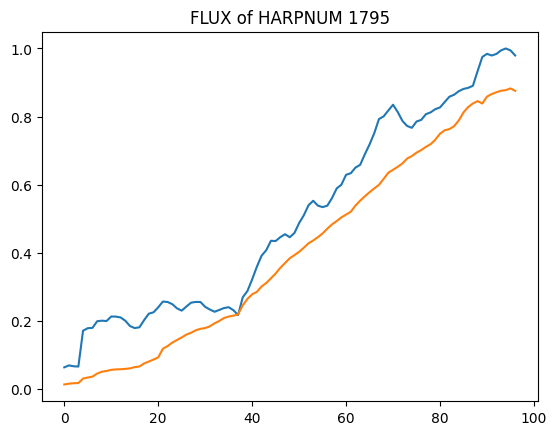

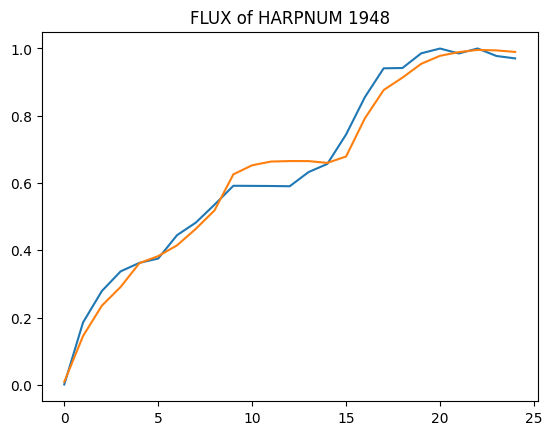

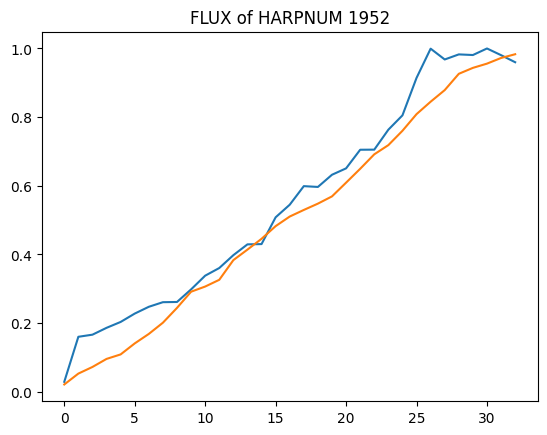

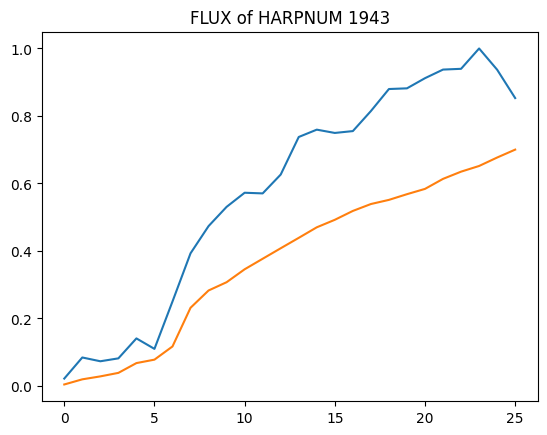

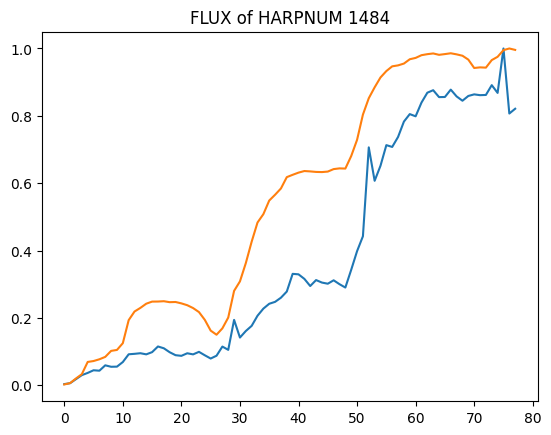

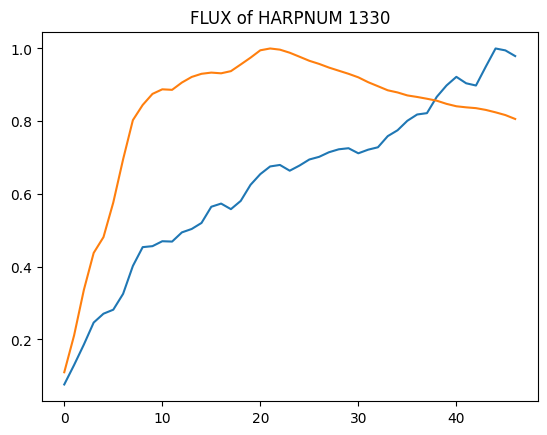

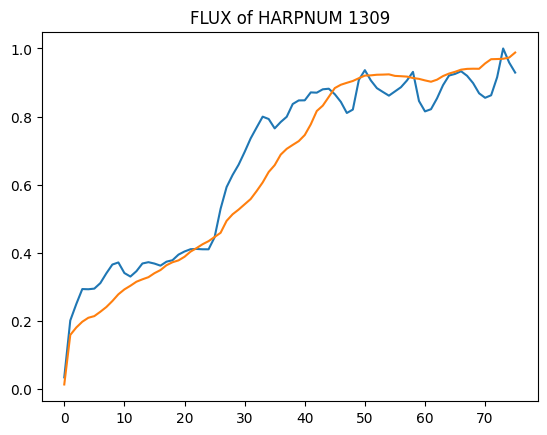

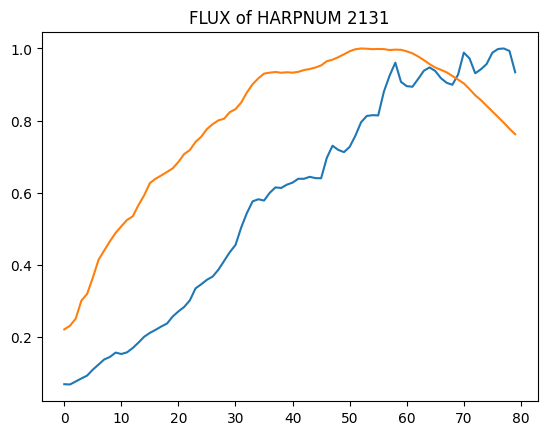

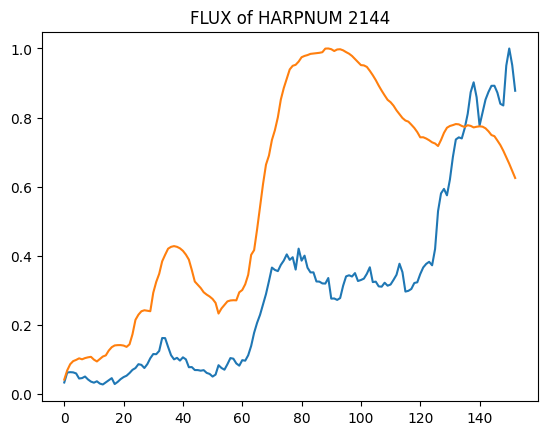

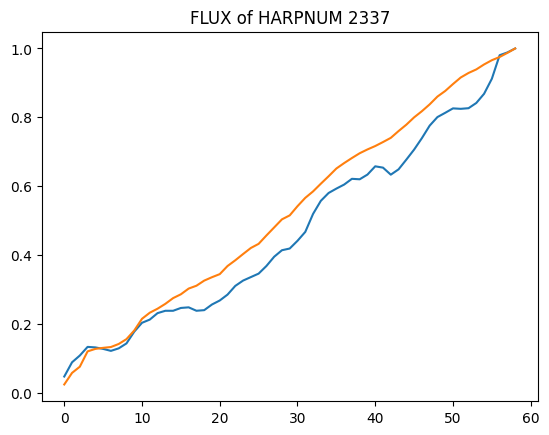

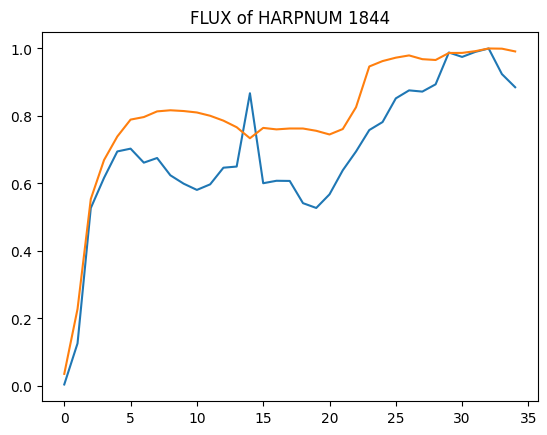

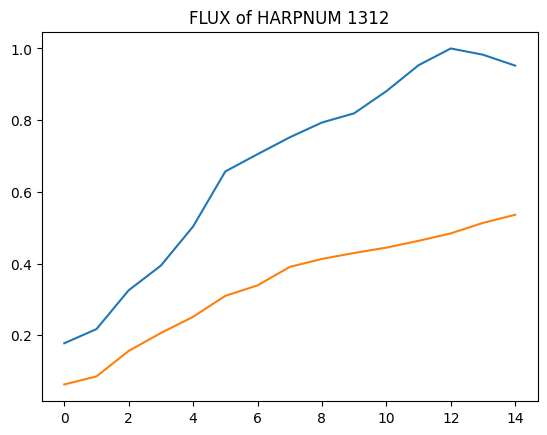

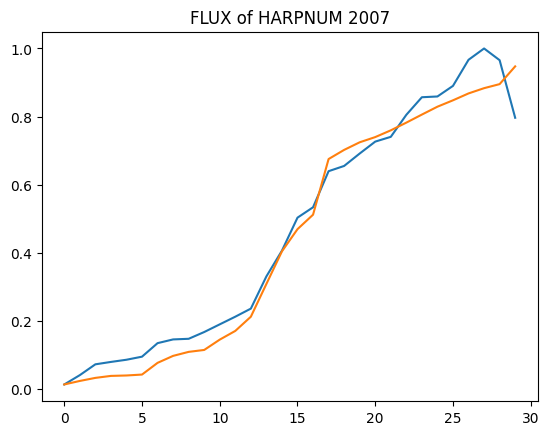

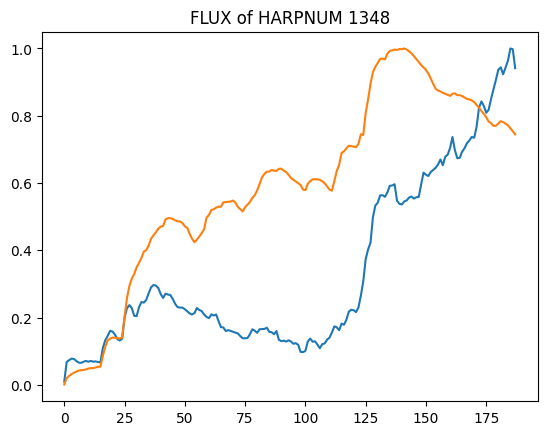

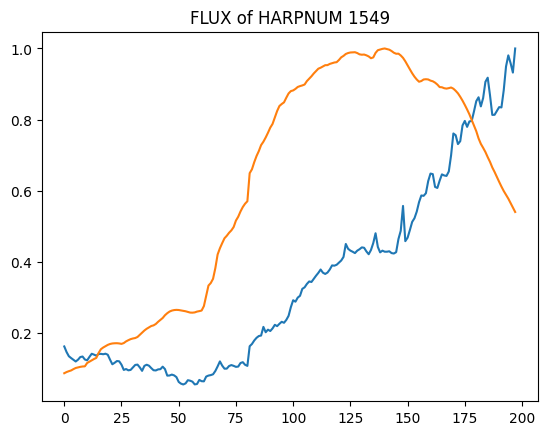

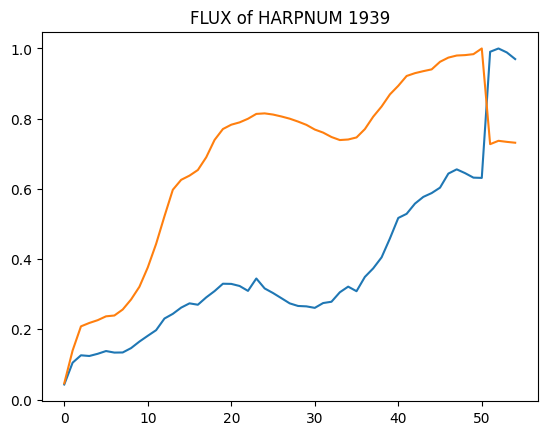

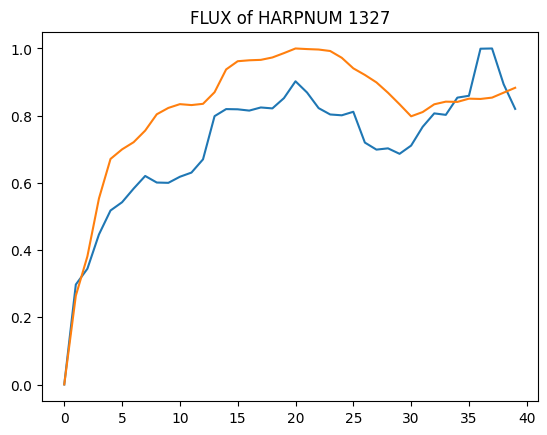

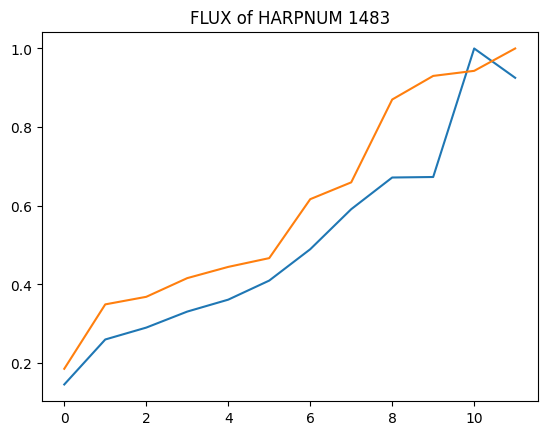

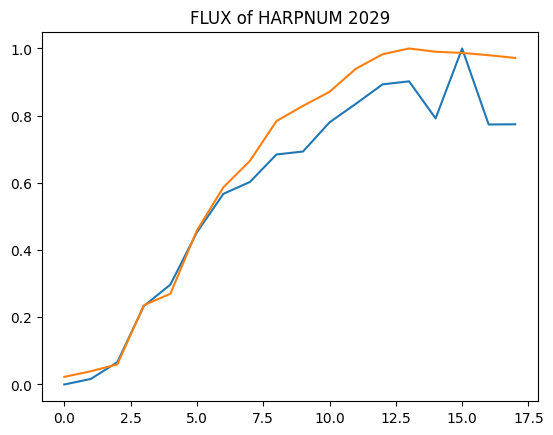

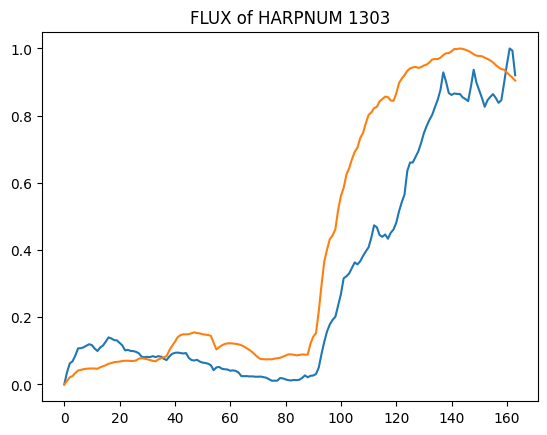

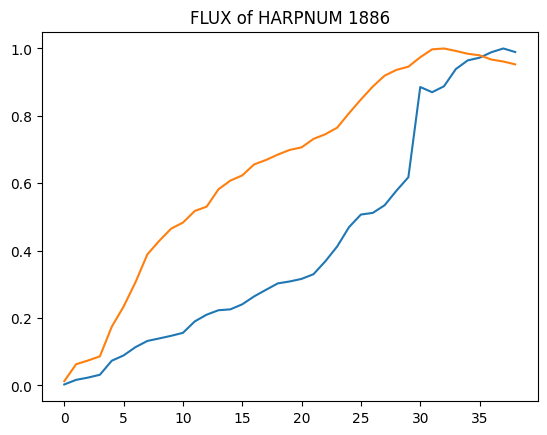

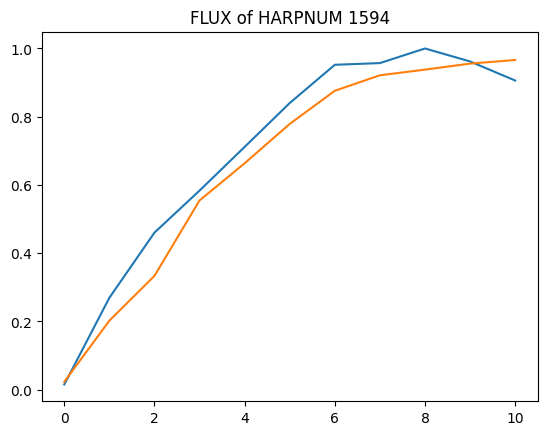

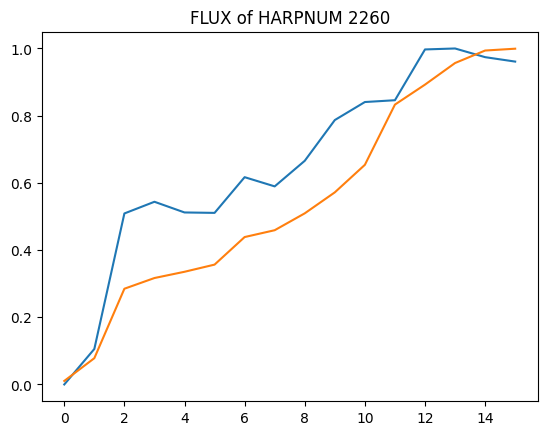

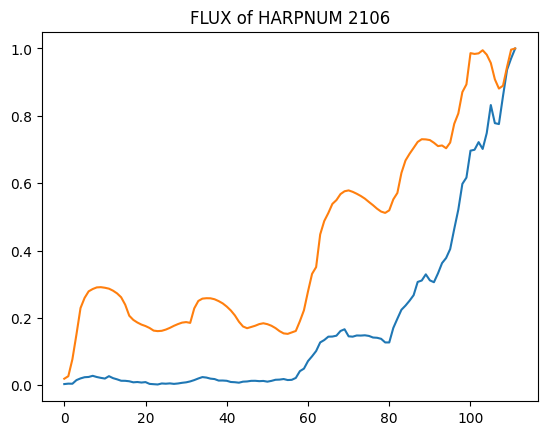

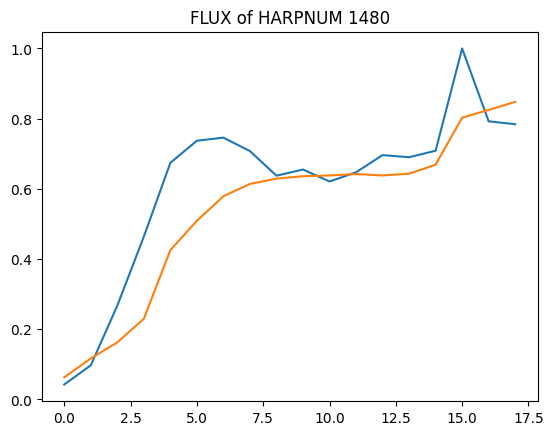

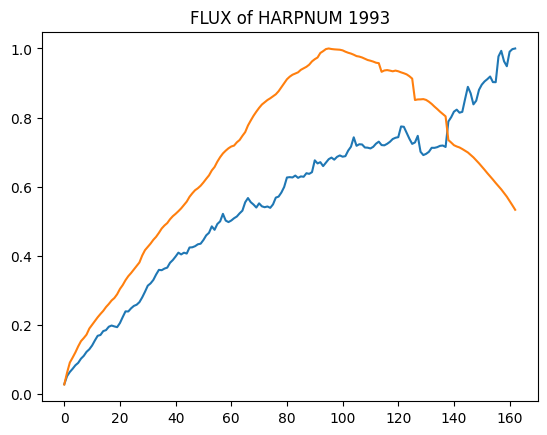

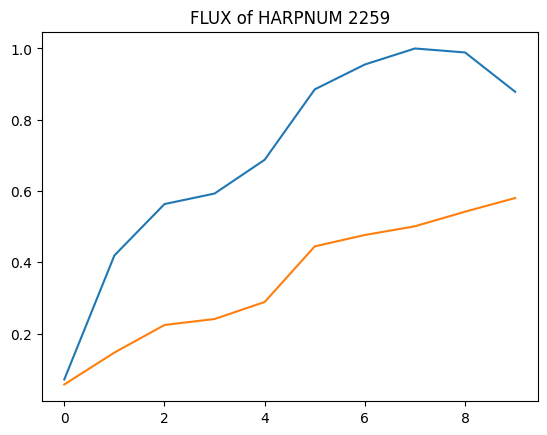

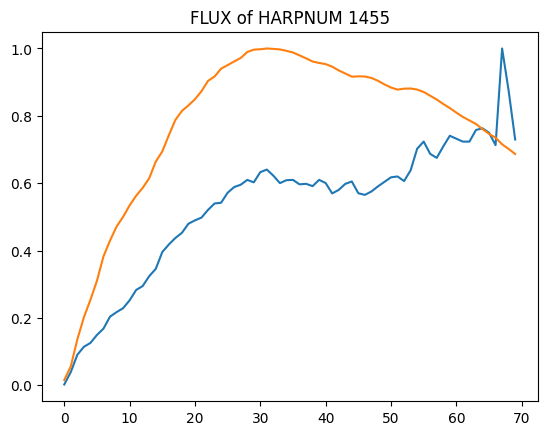

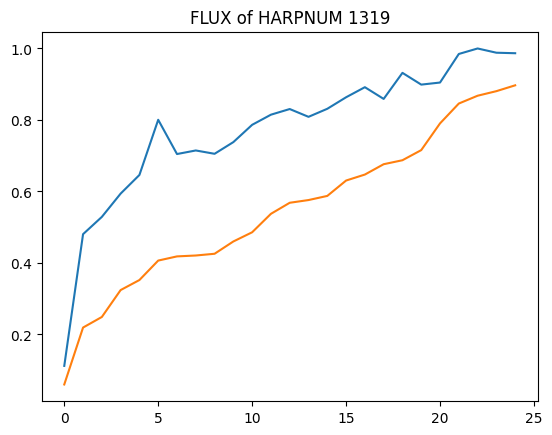

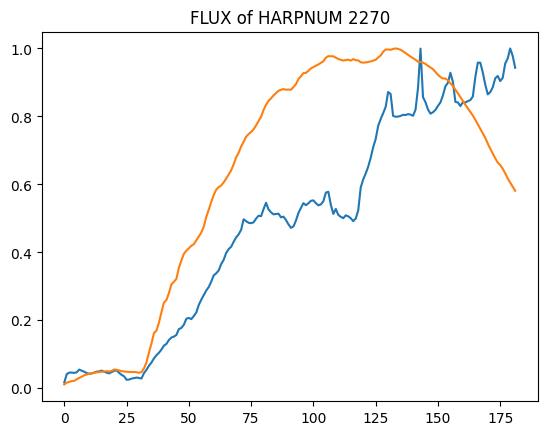

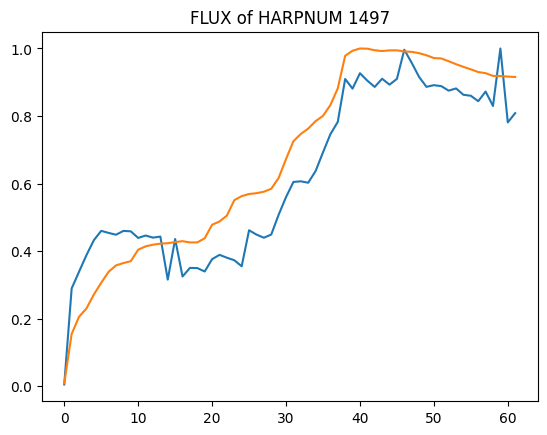

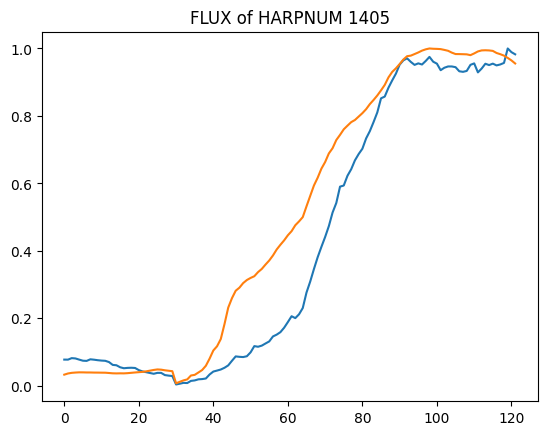

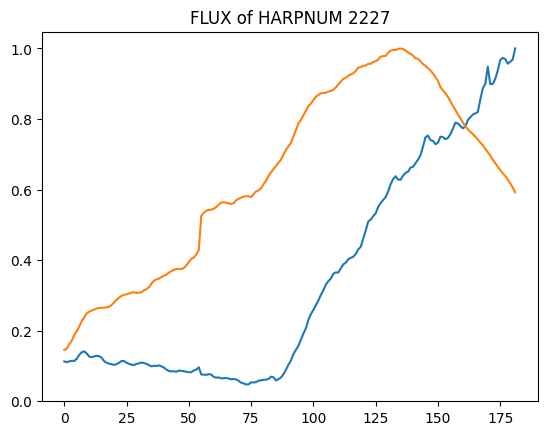

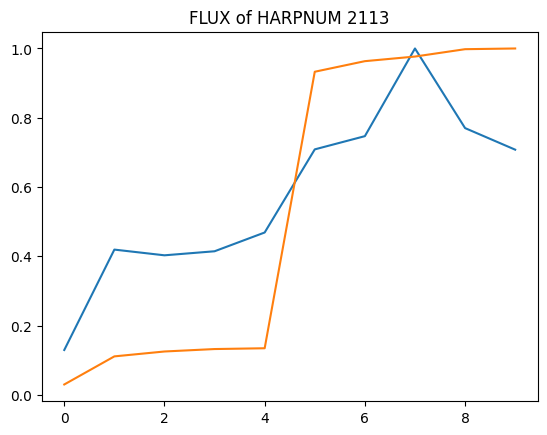

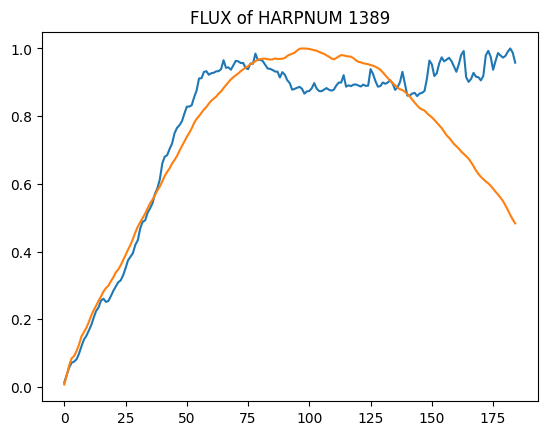

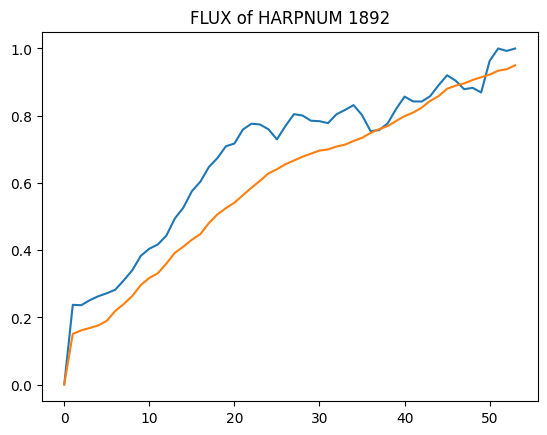

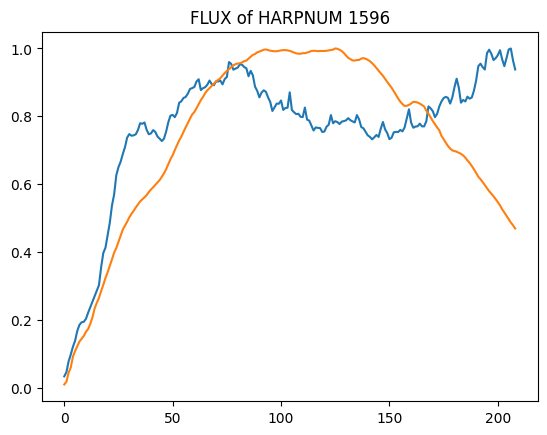

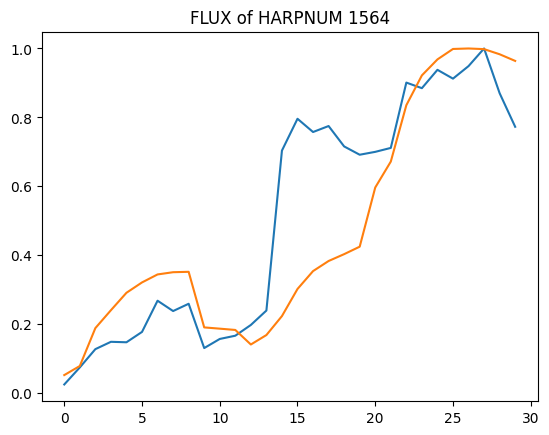

In [117]:
for hh in DF1.HARPNUM.unique():
    flux_values = DF1[DF1.HARPNUM == int(hh)]['NormF'].values
    size_values = DF1[DF1.HARPNUM == int(hh)]['NormS'].values
    plt.plot(flux_values)
    plt.plot(size_values)
    plt.title(f'FLUX of HARPNUM {hh}')
    plt.show()

In [116]:
DF1[DF1.HARPNUM == 2239]

,T_REC,NOAA_ARS,HARPNUM,MTOT,USFLUX,LON_MAX,LON_MIN,LAT_MAX,LAT_MIN,SIZE,LON,LAT,NormF,NormS
